# Домашнее задание 4: Создание Streamlit-проекта

**Задание:**

1. Реализуйте проект на Streamlit для задания из ДЗ-4.
2. Минимальный функционал — полное повторение кода урока по стримлиту (50 баллов из 100).
3. За каждое улучшение или изменение структуры проекта начисляется +10 баллов.
   - Улучшения могут включать: изменение способа ввода данных, способа вывода результатов, использование методов и функций, которые мы не затронули на уроке.
   - Простое добавление 5 различных графиков **не** считается улучшением, за график максимум +10 баллов, и за один и за 5.
  

**Советы для получения максимального балла:**
- Добавьте интерактивные элементы (например, ползунки, кнопки, выбор параметров).
- Улучшите визуализацию данных.
- Добавьте новые функции, улучшающие пользовательский опыт.

**Формат сдачи:**

- Файл `.py` с кодом Streamlit-приложения.
- Cсылка на развернутое приложение.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc

from mlxtend.plotting import plot_decision_regions

In [2]:
features_list = """1. Id number: 1 to 214
2. RI: refractive index
3. Na: Sodium
4. Mg: Magnesium
5. Al: Aluminum
6. Si: Silicon
7. K: Potassium
8. Ca: Calcium|
9. Ba: Barium
10. Fe: Iron
11. Type of glass: (class attribute)""".split("\n")

column_names = {}
for i, description in enumerate(features_list):
    column_names[i] = cols = (description.split(":")[0]).split(". ")[1]

column_names[0] = "ID"
column_names[i] = "glass_type"

In [3]:
# В будущем понадобится для красивых графиков
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 7)

df = pd.read_csv("data/glass.data", header=None)
df = df.rename(column_names, axis=1)

df.sample(10).sort_index()

,ID,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,glass_type
31,32,1.51747,12.84,3.50,1.14,73.27,0.56,8.55,0.00,0.00,1
46,47,1.51869,13.19,3.37,1.18,72.72,0.57,8.83,0.00,0.16,1
50,51,1.52320,13.72,3.72,0.51,71.75,0.09,10.06,0.00,0.16,1
54,55,1.51778,13.21,2.81,1.29,72.98,0.51,9.02,0.00,0.09,1
86,87,1.51569,13.24,3.49,1.47,73.25,0.38,8.03,0.00,0.00,2
90,91,1.51841,12.93,3.74,1.11,72.28,0.64,8.96,0.00,0.22,2
108,109,1.52222,14.43,0.00,1.00,72.67,0.10,11.52,0.00,0.08,2
124,125,1.52177,13.20,3.68,1.15,72.75,0.54,8.52,0.00,0.00,2
151,152,1.52127,14.32,3.90,0.83,71.50,0.00,9.49,0.00,0.00,3
194,195,1.51683,14.56,0.00,1.98,73.29,0.00,8.52,1.57,0.07,7


In [4]:
df.isna().sum()

ID            0
RI            0
Na            0
Mg            0
Al            0
Si            0
K             0
Ca            0
Ba            0
Fe            0
glass_type    0
dtype: int64

In [5]:
df['target'] = df['glass_type'].map({
    2: 0,  # Non-float Window → Класс 0
    5: 0,  # Container → Класс 0
    6: 0,  # Tableware → Класс 0
    1: 1,  # Float Window → Класс 1
    3: 1,  # Vehicle Window (Float) → Класс 1
    7: 1   # Headlamp → Класс 1
})

df["target"].value_counts()

target
1    116
0     98
Name: count, dtype: int64

In [6]:
df.dtypes.sort_values()

ID              int64
glass_type      int64
target          int64
RI            float64
Na            float64
Mg            float64
Al            float64
Si            float64
K             float64
Ca            float64
Ba            float64
Fe            float64
dtype: object

In [7]:
df["glass_type"].value_counts()

glass_type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [8]:
df.drop(columns=["ID", "glass_type"]).to_csv("data/data_hw5.csv", index=False)

In [9]:
df.nunique().sort_values()

target          2
glass_type      6
Fe             32
Ba             34
K              65
Mg             94
Al            118
Si            133
Na            142
Ca            143
RI            178
ID            214
dtype: int64

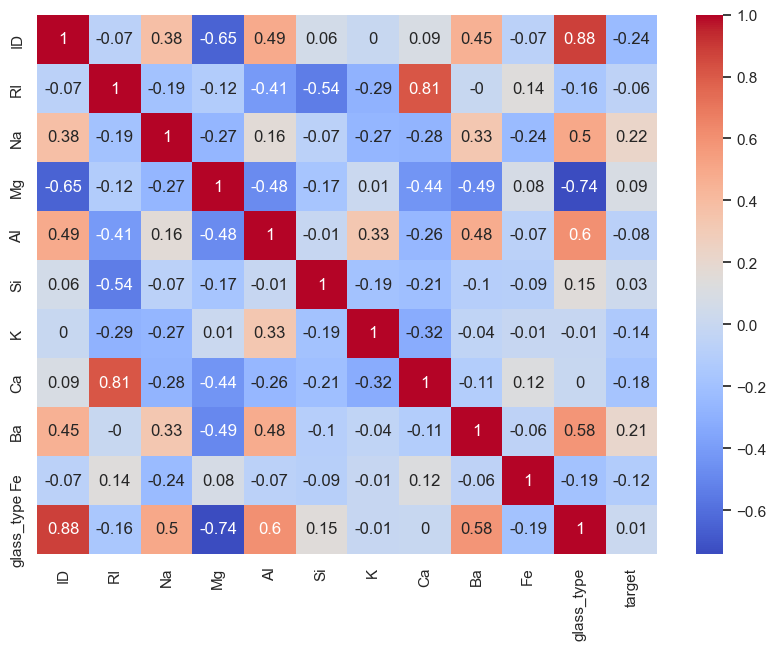

In [10]:
cor_mat = df.corr().round(2)[:-1]

cor_mat_plt, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cor_mat, annot=True, cmap="coolwarm");


In [11]:
cor_mat = df.corr().round(2)[:-1]
top3 = cor_mat.abs().sort_values(by="target", ascending=False)[:3].index.tolist()
top2 = cor_mat.abs().sort_values(by="target", ascending=False)[:2].index.tolist()


X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

scaler = StandardScaler()

columns = X_train.columns
X_train[columns] = scaler.fit_transform(X_train[columns])
X_test[columns] = scaler.transform(X_test[columns])

X_train_final = X_train[top2].values
X_test_final = X_test[top2].values

y_train_final = y_train.values
y_test_final = y_test.values

model_knn = KNeighborsClassifier(n_neighbors=3)
model_lr = LogisticRegression(max_iter=565)
model_dt = DecisionTreeClassifier(max_depth=5)

model_knn.fit(X_train_final, y_train_final)
model_lr.fit(X_train_final, y_train_final)
model_dt.fit(X_train_final, y_train_final);

In [23]:
def plot_dr():
    title="Границы решений для DT"

    xlabel=top2[0]
    ylabel=top2[1]

    fig, ax = plt.subplots(figsize=(8, 6))

    plot_decision_regions(X_train[top2].values, y_train.values, clf=model_dt, legend=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    return fig

fig.show()

C:\Users\b_jumaev\AppData\Local\Temp\ipykernel_83996\475722469.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
